In [13]:
import os
import re
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS

# =========================
# 用户参数
# =========================
INPUT_FILES = [
    "GALFA_HI_RA+DEC_012.00+26.35_N.fits",
    "GALFA_HI_RA+DEC_012.00+34.35_N.fits",
    "GALFA_HI_RA+DEC_020.00+26.35_N.fits",
    "GALFA_HI_RA+DEC_020.00+34.35_N.fits",
    "GALFA_HI_RA+DEC_028.00+26.35_N.fits",
    "GALFA_HI_RA+DEC_028.00+34.35_N.fits",
]

RA_MIN, RA_MAX = 10.0, 30.0
DEC_MIN, DEC_MAX = 24.0, 33.5

OUT_FITS = "GALFA_RA10_30_DEC24_33.fits"

# 分块：一次处理多少个速度道（避免内存波动）
ZSTEP = 16


# =========================
# 小工具
# =========================
def parse_ra_dec_from_name(fn: str):
    """
    从文件名里解析中心 RA/DEC（单位：deg）
    e.g. GALFA_HI_RA+DEC_012.00+26.35_N.fits -> (12.00, 26.35)
    """
    m = re.search(r"RA\+DEC_(\d+\.\d+)\+(\d+\.\d+)", fn)
    if not m:
        raise ValueError(f"无法从文件名解析RA/DEC: {fn}")
    return float(m.group(1)), float(m.group(2))


def world_to_pix_1based(w: WCS, ra_deg, dec_deg):
    """
    astropy.wcs 的 pixel 坐标是 0-based（origin=0）。
    这里用 origin=0，返回 float 像素坐标 (x, y) in 0-based。
    """
    x, y = w.wcs_world2pix(ra_deg, dec_deg, 0)
    return x, y

# 读一个参考 header，确定像素尺度、谱轴长度、blank等
with fits.open(INPUT_FILES[0], memmap=True, do_not_scale_image_data=True) as hdul0:
    h0 = hdul0[0].header
    w0 = WCS(h0)

BITPIX = int(h0["BITPIX"])  # 16 => int16
NAXIS3 = int(h0["NAXIS3"])  # 2048
BLANK = int(h0.get("BLANK", -32768))
BSCALE = float(h0.get("BSCALE", 1.0))
BZERO  = float(h0.get("BZERO", 0.0))

# 源像素大小（deg/px）
cdelt1 = float(h0["CDELT1"])  # RA per pixel (negative)
cdelt2 = float(h0["CDELT2"])  # DEC per pixel (positive)

# 输出空间尺寸（用同样的像素尺度）
nx = int(np.ceil((RA_MAX - RA_MIN) / abs(cdelt1)))
ny = int(np.ceil((DEC_MAX - DEC_MIN) / abs(cdelt2)))
shape_out = (NAXIS3, ny, nx)  # (z, y, x) in numpy

print("输出 shape (z,y,x):", shape_out)


# =========================
# 2) 构造输出 WCS（与源一致，只改 CRVAL/CRPIX 让范围对齐）
#    我们用“左下角世界坐标”锚定输出像素 (x=0,y=0)
# =========================
out_wcs = w0.deepcopy()

# 设定输出的参考像素为 (1,1) 对应世界坐标 (RA_MIN, DEC_MIN) 的左下角
# 注意 RA 轴 cdelt1 通常是负的：x 增大，RA 变小。
# 为了让输出覆盖 [RA_MIN, RA_MAX]，我们把 x=0 定义到 RA_MAX（右边界）更直观。
#
# 这里采用：输出图像的像素 (x=0, y=0) 对应 (RA_MAX, DEC_MIN)
# 这样随着 x 增大（向右），RA 递减，正好覆盖到 RA_MIN。
out_wcs.wcs.crpix[0] = 1.0
out_wcs.wcs.crpix[1] = 1.0
out_wcs.wcs.crval[0] = RA_MAX
out_wcs.wcs.crval[1] = DEC_MIN
out_wcs.wcs.cdelt[0] = cdelt1
out_wcs.wcs.cdelt[1] = cdelt2

# 谱轴保持不变（直接沿用）
out_wcs.wcs.crpix[2] = w0.wcs.crpix[2]
out_wcs.wcs.crval[2] = w0.wcs.crval[2]
out_wcs.wcs.cdelt[2] = w0.wcs.cdelt[2]
out_wcs.wcs.ctype[2] = w0.wcs.ctype[2]
out_wcs.wcs.cunit[2] = w0.wcs.cunit[2]


# =========================
# 3) 用 memmap 建立累加器（int32）和计数器（uint16）
# =========================
sum_map = np.memmap("temp_sum_i32.dat", dtype=np.int32, mode="w+", shape=shape_out)
cnt_map = np.memmap("temp_cnt_u16.dat", dtype=np.uint16, mode="w+", shape=shape_out)

sum_map[:] = 0
cnt_map[:] = 0


# =========================
# 4) 对每个输入文件：计算它在输出中的整数像素范围，然后按块复制累加
# =========================



for fn in INPUT_FILES:
    print("处理:", fn)
    with fits.open(fn, memmap=True, do_not_scale_image_data=True) as hdul:
        h = hdul[0].header
        w = WCS(h)

        # 输入 cube 覆盖范围（用你给的中心和 512/512 + cdelt 推出来最稳）
        # 也可以直接用 WCS 算四个角的世界坐标，这里用 header 的 CRVAL/CRPIX 更简单
        # 但为了避免符号搞错，我们用 WCS 把输入图像的像素边界映射到世界坐标，再映射到输出像素。

        # 输入像素边界（0-based）：[0, nx-1], [0, ny-1]
        in_nx = int(h["NAXIS1"])
        in_ny = int(h["NAXIS2"])

        # 取输入四个角的世界坐标
        corners_pix = np.array([
            [0,      0     ],
            [in_nx-1, 0     ],
            [0,      in_ny-1],
            [in_nx-1, in_ny-1],
        ], dtype=float)

        # wcs_world2pix/pix2world 2D 用 sky 子WCS更保险
        w2 = w.celestial
        out2 = out_wcs.celestial

        ras, decs = w2.wcs_pix2world(corners_pix[:,0], corners_pix[:,1], 0)

        # 把这些世界坐标映射到输出像素坐标
        ox, oy = out2.wcs_world2pix(ras, decs, 0)

        # 得到输出上的 bbox（float），再取整数范围
        x0 = int(np.floor(np.min(ox)))
        x1 = int(np.ceil (np.max(ox)))  # inclusive-ish
        y0 = int(np.floor(np.min(oy)))
        y1 = int(np.ceil (np.max(oy)))

        # 裁剪到输出范围
        x0c = max(0, x0)
        y0c = max(0, y0)
        x1c = min(nx-1, x1)
        y1c = min(ny-1, y1)

        if x0c > x1c or y0c > y1c:
            print("  -> 与目标区域无交集，跳过")
            continue

        # 输出切片（python slice 右开区间）
        xs_out = slice(x0c, x1c + 1)
        ys_out = slice(y0c, y1c + 1)

        # 为了找到对应输入切片：把输出切片的角点转回世界，再转到输入像素
        # 使用输出 bbox 的四个角点
        out_corners = np.array([
            [x0c, y0c],
            [x1c, y0c],
            [x0c, y1c],
            [x1c, y1c],
        ], dtype=float)

        ra2, dec2 = out2.wcs_pix2world(out_corners[:,0], out_corners[:,1], 0)
        ix, iy = w2.wcs_world2pix(ra2, dec2, 0)

        ix0 = int(np.floor(np.min(ix)))
        ix1 = int(np.ceil (np.max(ix)))
        iy0 = int(np.floor(np.min(iy)))
        iy1 = int(np.ceil (np.max(iy)))

        # 裁剪到输入范围
        ix0c = max(0, ix0)
        iy0c = max(0, iy0)
        ix1c = min(in_nx-1, ix1)
        iy1c = min(in_ny-1, iy1)

        # 重新同步输出范围（因为输入裁剪可能改变尺寸）
        # 这里用最简单且安全的方法：根据裁剪后的输入范围，再映射到输出范围，保证两者尺寸一致
        in_corners2 = np.array([
            [ix0c, iy0c],
            [ix1c, iy0c],
            [ix0c, iy1c],
            [ix1c, iy1c],
        ], dtype=float)
        ra3, dec3 = w2.wcs_pix2world(in_corners2[:,0], in_corners2[:,1], 0)
        ox2, oy2 = out2.wcs_world2pix(ra3, dec3, 0)

        x0c2 = int(np.round(np.min(ox2)))
        x1c2 = int(np.round(np.max(ox2)))
        y0c2 = int(np.round(np.min(oy2)))
        y1c2 = int(np.round(np.max(oy2)))

        # 最终切片
        xs_out = slice(max(0, x0c2), min(nx, x1c2 + 1))
        ys_out = slice(max(0, y0c2), min(ny, y1c2 + 1))
        xs_in  = slice(ix0c, ix0c + (xs_out.stop - xs_out.start))
        ys_in  = slice(iy0c, iy0c + (ys_out.stop - ys_out.start))

        # sanity check：确保尺寸一致
        if (xs_out.stop - xs_out.start) != (xs_in.stop - xs_in.start) or (ys_out.stop - ys_out.start) != (ys_in.stop - ys_in.start):
            raise RuntimeError(f"切片尺寸不一致: {fn}\n  out x={xs_out}, y={ys_out}\n  in  x={xs_in}, y={ys_in}")

        data = hdul[0].data  # 现在这是原始 int16，可 memmap
        if not (np.issubdtype(data.dtype, np.signedinteger) and data.dtype.itemsize == 2):
            raise RuntimeError(
            f"{fn} 读取到的不是 16-bit signed integer，而是 {data.dtype}"
            )
        for z0 in range(0, NAXIS3, ZSTEP):
            z1 = min(NAXIS3, z0 + ZSTEP)

            slab = data[z0:z1, ys_in, xs_in]  # int16 view
            mask = (slab != BLANK)

            sum_map[z0:z1, ys_out, xs_out] += slab.astype(np.int32) * mask.astype(np.int32)
            cnt_map[z0:z1, ys_out, xs_out] += mask.astype(np.uint16)

# =========================
# 5) 输出：sum/cnt -> int16；无数据写 BLANK
# =========================
print("正在生成最终 int16 输出...")
out_i16 = np.memmap("temp_out_i16.dat", dtype=np.int16, mode="w+", shape=shape_out)

for z0 in range(0, NAXIS3, ZSTEP):
    z1 = min(NAXIS3, z0 + ZSTEP)
    s = sum_map[z0:z1]
    c = cnt_map[z0:z1]

    out_block = np.empty_like(s, dtype=np.int16)
    nodata = (c == 0)

    # 取平均（四舍五入到最近整数）
    avg = np.rint(s / np.maximum(c, 1)).astype(np.int32)
    avg = np.clip(avg, -32768, 32767).astype(np.int16)

    out_block[:] = avg
    out_block[nodata] = np.int16(BLANK)

    out_i16[z0:z1] = out_block

out_i16.flush()


# =========================
# 6) 写 FITS（保持 int16 + BSCALE/BZERO/BLANK）
# =========================
print("写入 FITS:", OUT_FITS)

out_header = out_wcs.to_header()
# 继承关键物理量信息
out_header["BUNIT"] = h0.get("BUNIT", "")
out_header["BSCALE"] = BSCALE
out_header["BZERO"] = BZERO
out_header["BLANK"] = BLANK

hdu0 = fits.PrimaryHDU(data=out_i16, header=out_header)
fits.HDUList([hdu0]).writeto(OUT_FITS, overwrite=True)

# =========================
# 7) 清理临时文件
# =========================
print("清理临时文件...")
del sum_map, cnt_map, out_i16
for fn in ["temp_sum_i32.dat", "temp_cnt_u16.dat", "temp_out_i16.dat"]:
    if os.path.exists(fn):
        os.remove(fn)

print("完成。")


输出 shape (z,y,x): (2048, 570, 1200)
处理: GALFA_HI_RA+DEC_012.00+26.35_N.fits
处理: GALFA_HI_RA+DEC_012.00+34.35_N.fits
处理: GALFA_HI_RA+DEC_020.00+26.35_N.fits
处理: GALFA_HI_RA+DEC_020.00+34.35_N.fits
处理: GALFA_HI_RA+DEC_028.00+26.35_N.fits
处理: GALFA_HI_RA+DEC_028.00+34.35_N.fits
正在生成最终 int16 输出...
写入 FITS: GALFA_RA10_30_DEC24_33.fits
清理临时文件...
完成。


In [12]:
import os
import re
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS

INPUT_FILES = [
    "GALFA_HI_RA+DEC_012.00+26.35_N.fits",
    "GALFA_HI_RA+DEC_012.00+34.35_N.fits",
    "GALFA_HI_RA+DEC_020.00+26.35_N.fits",
    "GALFA_HI_RA+DEC_020.00+34.35_N.fits",
    "GALFA_HI_RA+DEC_028.00+26.35_N.fits",
    "GALFA_HI_RA+DEC_028.00+34.35_N.fits",
]

RA_MIN, RA_MAX = 10.0, 30.0
DEC_MIN, DEC_MAX = 24.0, 33.5

OUT_FITS = "GALFA_RA10_30_DEC24_33_float32.fits"

ZSTEP = 16  # 速度轴分块大小，避免内存峰值

def parse_ra_dec_from_name(fn: str):
    m = re.search(r"RA\+DEC_(\d+\.\d+)\+(\d+\.\d+)", fn)
    if not m:
        raise ValueError(f"无法从文件名解析RA/DEC: {fn}")
    return float(m.group(1)), float(m.group(2))

# 读取参考 header/WCS
with fits.open(INPUT_FILES[0], memmap=True, do_not_scale_image_data=True) as hdul0:
    h0 = hdul0[0].header
    w0 = WCS(h0)

NAXIS3 = int(h0["NAXIS3"])
BLANK = int(h0.get("BLANK", -32768))

cdelt1 = float(h0["CDELT1"])
cdelt2 = float(h0["CDELT2"])

nx = int(np.ceil((RA_MAX - RA_MIN) / abs(cdelt1)))
ny = int(np.ceil((DEC_MAX - DEC_MIN) / abs(cdelt2)))
shape_out = (NAXIS3, ny, nx)  # (z, y, x)

print("输出 shape (z,y,x):", shape_out)

# 构造输出WCS（与源一致，只锚定到目标范围）
out_wcs = w0.deepcopy()
out_wcs.wcs.crpix[0] = 1.0
out_wcs.wcs.crpix[1] = 1.0
out_wcs.wcs.crval[0] = RA_MAX
out_wcs.wcs.crval[1] = DEC_MIN
out_wcs.wcs.cdelt[0] = cdelt1
out_wcs.wcs.cdelt[1] = cdelt2

# 只取天球2D WCS 做像素框映射
out2 = out_wcs.celestial

# 输出：float32 �� count（count 用 uint16 足够）
sum_map = np.memmap("temp_sum_f32.dat", dtype=np.float32, mode="w+", shape=shape_out)
cnt_map = np.memmap("temp_cnt_u16.dat", dtype=np.uint16, mode="w+", shape=shape_out)
sum_map[:] = np.float32(0.0)
cnt_map[:] = np.uint16(0)

for fn in INPUT_FILES:
    print("处理:", fn)
    with fits.open(fn, memmap=True, do_not_scale_image_data=True) as hdul:
        h = hdul[0].header
        w = WCS(h)
        w2 = w.celestial

        in_nx = int(h["NAXIS1"])
        in_ny = int(h["NAXIS2"])
        data = hdul[0].data  # 原始 >i2

        # 输入四角 -> 世界 -> 输出像素，算输出 bbox
        corners_pix = np.array([[0,0],[in_nx-1,0],[0,in_ny-1],[in_nx-1,in_ny-1]], dtype=np.float64)
        ras, decs = w2.wcs_pix2world(corners_pix[:,0], corners_pix[:,1], 0)
        ox, oy = out2.wcs_world2pix(ras, decs, 0)

        x0 = int(np.floor(np.min(ox))); x1 = int(np.ceil(np.max(ox)))
        y0 = int(np.floor(np.min(oy))); y1 = int(np.ceil(np.max(oy)))

        # 裁剪到输出范围
        x0c = max(0, x0); y0c = max(0, y0)
        x1c = min(nx-1, x1); y1c = min(ny-1, y1)
        if x0c > x1c or y0c > y1c:
            print("  -> 与目标区域无交集，跳过")
            continue

        # 输出 bbox 四角 -> 世界 -> 输入像素，得到输入切片
        out_corners = np.array([[x0c,y0c],[x1c,y0c],[x0c,y1c],[x1c,y1c]], dtype=np.float64)
        ra2, dec2 = out2.wcs_pix2world(out_corners[:,0], out_corners[:,1], 0)
        ix, iy = w2.wcs_world2pix(ra2, dec2, 0)

        ix0 = int(np.floor(np.min(ix))); ix1 = int(np.ceil(np.max(ix)))
        iy0 = int(np.floor(np.min(iy))); iy1 = int(np.ceil(np.max(iy)))

        # 裁剪到输入范围
        ix0c = max(0, ix0); iy0c = max(0, iy0)
        ix1c = min(in_nx-1, ix1); iy1c = min(in_ny-1, iy1)

        # 用裁剪后的输入角点反算输出，确保尺寸一致（取 round 对齐到整数格）
        in_corners2 = np.array([[ix0c,iy0c],[ix1c,iy0c],[ix0c,iy1c],[ix1c,iy1c]], dtype=np.float64)
        ra3, dec3 = w2.wcs_pix2world(in_corners2[:,0], in_corners2[:,1], 0)
        ox2, oy2 = out2.wcs_world2pix(ra3, dec3, 0)

        x0o = int(np.round(np.min(ox2))); x1o = int(np.round(np.max(ox2)))
        y0o = int(np.round(np.min(oy2))); y1o = int(np.round(np.max(oy2)))

        xs_out = slice(max(0, x0o), min(nx, x1o+1))
        ys_out = slice(max(0, y0o), min(ny, y1o+1))
        xs_in  = slice(ix0c, ix0c + (xs_out.stop - xs_out.start))
        ys_in  = slice(iy0c, iy0c + (ys_out.stop - ys_out.start))

        if (xs_out.stop-xs_out.start) != (xs_in.stop-xs_in.start) or (ys_out.stop-ys_out.start) != (ys_in.stop-ys_in.start):
            raise RuntimeError(f"切片尺寸不一致: {fn}")

        # 分块累加：把 int16 转成 float32（明确指定，避免 float64）
        for z0 in range(0, NAXIS3, ZSTEP):
            z1 = min(NAXIS3, z0 + ZSTEP)
            slab_i16 = data[z0:z1, ys_in, xs_in]  # >i2
            valid = (slab_i16 != BLANK)

            slab_f32 = slab_i16.astype(np.float32, copy=False)  # 这里会转换端序，但保持 float32
            # BLANK 的地方不参与
            sum_map[z0:z1, ys_out, xs_out] += slab_f32 * valid.astype(np.float32)
            cnt_map[z0:z1, ys_out, xs_out] += valid.astype(np.uint16)

# 生成最终平均值：float32
print("生成最终 float32 cube...")
out_f32 = np.memmap("temp_out_f32.dat", dtype=np.float32, mode="w+", shape=shape_out)

for z0 in range(0, NAXIS3, ZSTEP):
    z1 = min(NAXIS3, z0 + ZSTEP)
    s = sum_map[z0:z1]
    c = cnt_map[z0:z1].astype(np.float32)

    # 避免除零：没有覆盖的像素写 NaN
    out_block = np.full_like(s, np.nan, dtype=np.float32)
    mask = c > 0
    out_block[mask] = (s[mask] / c[mask]).astype(np.float32)

    out_f32[z0:z1] = out_block

out_f32.flush()

# 写 FITS：float32（BITPIX = -32）
print("写入 FITS:", OUT_FITS)
out_header = out_wcs.to_header()
out_header["BUNIT"] = h0.get("BUNIT", "")
# float32 输出时，不再写 BSCALE/BZERO/BLANK（用 NaN 表示空值）
hdu0 = fits.PrimaryHDU(data=out_f32, header=out_header)
fits.HDUList([hdu0]).writeto(OUT_FITS, overwrite=True)

# 清理临时文件
print("清理临时文件...")
del sum_map, cnt_map, out_f32
for fn in ["temp_sum_f32.dat", "temp_cnt_u16.dat", "temp_out_f32.dat"]:
    if os.path.exists(fn):
        os.remove(fn)

print("完成。")

输出 shape (z,y,x): (2048, 570, 1200)
处理: GALFA_HI_RA+DEC_012.00+26.35_N.fits
处理: GALFA_HI_RA+DEC_012.00+34.35_N.fits
处理: GALFA_HI_RA+DEC_020.00+26.35_N.fits
处理: GALFA_HI_RA+DEC_020.00+34.35_N.fits
处理: GALFA_HI_RA+DEC_028.00+26.35_N.fits
处理: GALFA_HI_RA+DEC_028.00+34.35_N.fits
生成最终 float32 cube...
写入 FITS: GALFA_RA10_30_DEC24_33_float32.fits
清理临时文件...
完成。


随机抽取的速度通道: 954
差异统计:
  平均差异: 3.361752e-06
  最大差异: 0.5


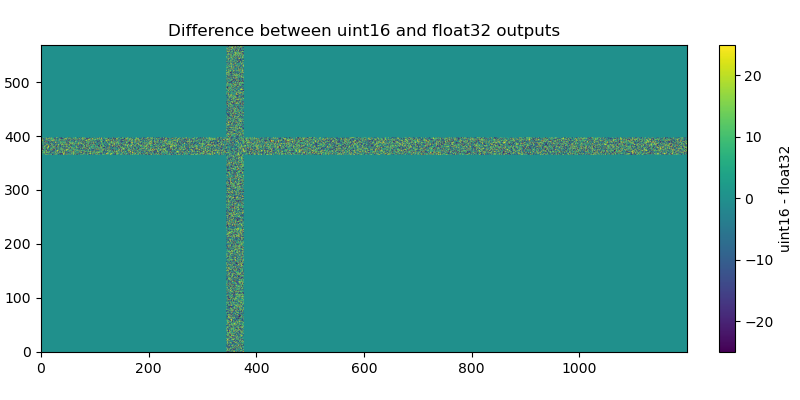

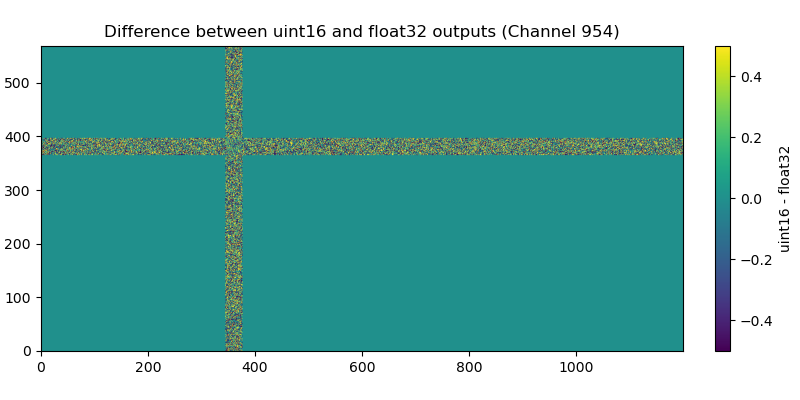

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import gc
%matplotlib widget

# 比较uint16和float32的结果差异
with fits.open("GALFA_RA10_30_DEC24_33.fits") as hdul_i16, fits.open("GALFA_RA10_30_DEC24_33_float32.fits") as hdul_f32:
    wcs = WCS(hdul_i16[0].header)  # 读一个 WCS 来对齐显示坐标轴
    data_i16 = hdul_i16[0].data.astype(np.float32)
    data_f32 = hdul_f32[0].data
    hdul_i16.close()
    hdul_f32.close()

    diff = data_i16 - data_f32
    diff_moment0 = np.nansum(diff, axis=0)  # 速度轴求和，看看空间上的差异分布
    # 随机抽取一个速度通道对比
    random_channel = np.random.randint(0, data_i16.shape[0])
    print(f"随机抽取的速度通道: {random_channel}")

    print("差异统计:")
    print("  平均差异:", np.mean(diff))
    print("  最大差异:", np.max(diff))

    # 可以根据需要输出差异分布图
    fig, ax = plt.subplots(
    figsize=(8,4), layout="compressed" # , subplot_kw={"projection": wcs.celestial}
    )
    plt.imshow(diff_moment0, origin='lower', vmin=-25, vmax=25)
    plt.colorbar(label='uint16 - float32')
    plt.title('Difference between uint16 and float32 outputs')
    # lon = ax.coords[0]
    # lat = ax.coords[1]
    # lon.set_major_formatter("dd")
    # lat.set_major_formatter("dd")
    # lon.set_axislabel("RA")
    # lat.set_axislabel("Dec")
    plt.show()

    fig, ax = plt.subplots(
    figsize=(8,4), layout="compressed" # , subplot_kw={"projection": wcs.celestial}
    )
    plt.imshow(diff[random_channel], origin='lower', vmin=-0.5, vmax=0.5)
    plt.colorbar(label='uint16 - float32')
    plt.title(f'Difference between uint16 and float32 outputs (Channel {random_channel})')
    # lon = ax.coords[0]
    # lat = ax.coords[1]
    # lon.set_major_formatter("dd")
    # lat.set_major_formatter("dd")
    # lon.set_axislabel("RA")
    # lat.set_axislabel("Dec")
    plt.show()
    del data_i16, data_f32, diff, diff_moment0
    gc.collect()